## 1. Insert Dataset and Combine

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 100)

mc_df = pd.read_csv("../data/processed/Counts/MCcounts.csv")
my_df = pd.read_csv("../data/processed/Counts/counts.csv")

print("Marcus Carpenter dataset:", mc_df.shape)
print("My dataset:", my_df.shape)

Marcus Carpenter dataset: (363, 274)
My dataset: (101, 288)


In [2]:
print("Marcus Carpenter dataset classes:")
print(mc_df["label"].value_counts())

print("\nMy dataset classes:")
print(my_df["label"].value_counts())

print("\nWhere 0 is benign and 1 is ransomware.")
print("In total we have 363 ransomware data points and 101 benign data points.")

Marcus Carpenter dataset classes:
label
1    262
0    101
Name: count, dtype: int64

My dataset classes:
label
1    101
Name: count, dtype: int64

Where 0 is benign and 1 is ransomware.
In total we have 363 ransomware data points and 101 benign data points.


In [3]:
mc_features = mc_df.drop(columns=["label", "report_id"])
my_features = my_df.drop(columns=["label", "report_id"])

mc_all_zero = (mc_features.sum(axis=1) == 0)
my_all_zero = (my_features.sum(axis=1) == 0)

print("MC all-zero samples:", mc_all_zero.sum())
print("My all-zero samples:", my_all_zero.sum())

MC all-zero samples: 0
My all-zero samples: 5


In [4]:
# Remove data points with all zero values
mc_clean = mc_df.copy()
my_clean = my_df.loc[~my_all_zero].copy()

print("MC dataset:", mc_clean.shape)
print("My dataset:", my_clean.shape)

MC dataset: (363, 274)
My dataset: (96, 288)


In [5]:
non_features = ["label", "report_id"]

mc_features = [col for col in mc_clean.columns if col not in non_features]
my_features = [col for col in my_clean.columns if col not in non_features]
all_features = sorted(set(mc_features) | set(my_features))

print("MC API features:", len(mc_features))
print("My API features:", len(my_features))
print("Total combined API features:", len(all_features))

MC API features: 272
My API features: 286
Total combined API features: 340


In [6]:
mc_X = mc_clean.reindex(columns=all_features, fill_value=0)
my_X = my_clean.reindex(columns=all_features, fill_value=0)

print("MC feature matrix:", mc_X.shape)
print("My feature matrix:", my_X.shape)

MC feature matrix: (363, 340)
My feature matrix: (96, 340)


In [7]:
mc_X["label"] = mc_clean["label"].values
my_X["label"] = my_clean["label"].values
combined_df = pd.concat([mc_X, my_X],ignore_index=True)

print("Combined dataset:", combined_df.shape)

Combined dataset: (459, 341)


## 2. Exploratory Data Analysis

In [8]:
print(combined_df["label"].value_counts())

label
1    358
0    101
Name: count, dtype: int64


In [9]:
df = combined_df.copy()

display(df.describe())
print("\nUnique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()}")
# percentage of zeroes per API
api_cols = df.columns.drop("label")
zero_percent = (df[api_cols] == 0).mean() * 100
print(zero_percent.describe())
     

,BCryptCloseAlgorithmProvider,BCryptCreateHash,BCryptDecrypt,BCryptDestroyHash,BCryptEncrypt,BCryptGenRandom,BCryptImportKeyPair,BCryptOpenAlgorithmProvider,CLSIDFromProgID,ChangeWindowMessageFilter,...,select,send,sendto,setsockopt,shutdown,socket,srand,sysenter,system,label
count,459.000000,459.000000,459.000000,459.000000,459.000000,459.00000,459.000000,459.000000,459.000000,459.000000,...,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000
mean,1.779956,3.544662,0.655773,7.045752,15.644880,30.32244,0.004357,1.681917,0.071895,0.507625,...,16.108932,4.052288,9.843137,1.507625,5.350763,12.631808,1.013072,0.409586,0.002179,0.779956
std,9.857807,28.467550,14.049477,93.489369,220.152206,291.31757,0.093352,9.596392,0.392694,1.009478,...,158.892706,19.217711,144.114286,17.972609,35.848192,111.047914,6.999676,1.773777,0.046676,0.414728
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,1.000000
max,70.000000,514.000000,301.000000,1928.000000,3520.000000,3602.00000,2.000000,68.000000,3.000000,6.000000,...,2373.000000,382.000000,2958.000000,383.000000,255.000000,2286.000000,111.000000,13.000000,1.000000,1.000000



Unique values per column:
  BCryptCloseAlgorithmProvider: 17
  BCryptCreateHash: 22
  BCryptDecrypt: 2
  BCryptDestroyHash: 18
  BCryptEncrypt: 6
  BCryptGenRandom: 18
  BCryptImportKeyPair: 2
  BCryptOpenAlgorithmProvider: 13
  CLSIDFromProgID: 4
  ChangeWindowMessageFilter: 5
  CoCreateInstance: 88
  CoCreateInstanceEx: 21
  CoGetClassObject: 36
  CoGetObject: 4
  CommandLineToArgvW: 5
  ConnectEx: 13
  ControlService: 8
  CopyFileA: 3
  CopyFileExW: 3
  CopyFileW: 11
  CreateDirectoryW: 35
  CreateProcessA: 10
  CreateProcessInternalW: 16
  CreateProcessW: 11
  CreateProcessWithTokenW: 2
  CreateRemoteThread: 5
  CreateRemoteThreadEx: 32
  CreateServiceA: 2
  CreateServiceW: 2
  CreateThread: 48
  CreateTimerQueueTimer: 9
  CreateToolhelp32Snapshot: 29
  CryptAcquireContextA: 20
  CryptAcquireContextW: 21
  CryptCreateHash: 19
  CryptDecodeObjectEx: 8
  CryptDecrypt: 9
  CryptDestroyHash: 16
  CryptDestroyKey: 32
  CryptEncrypt: 38
  CryptExportKey: 14
  CryptGenKey: 14
  CryptGenR

In [10]:
print(zero_percent.sort_values(ascending=False).head(20))

system                        99.782135
GetCurrentHwProfileW          99.782135
DnsQuery_A                    99.782135
CryptImportPublicKeyInfo      99.782135
ExitWindowsEx                 99.782135
FindWindowExA                 99.782135
URLDownloadToFileW            99.782135
WMI_GetObject                 99.782135
WNetUseConnectionW            99.782135
CreateProcessWithTokenW       99.782135
BCryptDecrypt                 99.782135
GetWriteWatch                 99.782135
InternetWriteFile             99.782135
NtQueryMultipleValueKey       99.782135
InternetReadFile              99.782135
BCryptImportKeyPair           99.782135
RegDeleteValueA               99.782135
RasConnectionNotificationW    99.782135
EnumCalendarInfoW             99.782135
GetDiskFreeSpaceA             99.782135
dtype: float64


Label value counts:
label
1    358
0    101
Name: count, dtype: int64

Class balance (%):
label
1    77.995643
0    22.004357
Name: proportion, dtype: float64


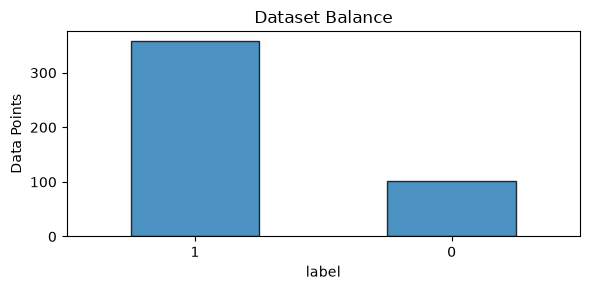


Where 1 is ransomware and 0 is benign.


In [11]:
import matplotlib.pyplot as plot

df = combined_df.copy()
print("Label value counts:")
print(df["label"].value_counts())
print("\nClass balance (%):")
print(df["label"].value_counts(normalize=True) * 100)

plot.figure(figsize=(6, 3))
df["label"].value_counts().plot(kind="bar", edgecolor="black", alpha=0.8)
plot.title(f"Dataset Balance")
plot.ylabel("Data Points")
plot.xticks(rotation=0)
plot.tight_layout()
plot.show()
print("\nWhere 1 is ransomware and 0 is benign.")

From here we can see that the dataset has a 78:22 class imabalnce, where Ransomware data points is heavily represented relative to Benign data points. Hence, we will be looking at dataset balancing techniques.

# 3. Data Preprocessing and Training Experiments

# 3.1 XGBoost Experiments
- XGBoost with Mutual Information Classifier
- XGBoost with SMOTE

In [26]:
import pandas as pd
import time
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = combined_df.copy()
X = df.drop(columns=["label"])
y = df["label"]

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_configs = {"Full": None, "Top 50": 50, "Top 100": 100, "Top 250": 250}

param_grid_base = {
    "clf__n_estimators": [50, 100, 200, 300],
    "clf__max_depth": [2, 3, 4, 5],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 1.0],
    "clf__min_child_weight": [1, 3, 5],
    "clf__gamma": [0, 0.1, 0.3],
}

def select_features_mi(X_train, y_train, n=None):
    if n is None:
        return X_train.columns.tolist()
    mi = mutual_info_classif(X_train, y_train, random_state=42)
    ranked = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
    return ranked.head(n).index.tolist()

def select_features_xgb_importance(X_train, y_train, n=None):
    if n is None:
        return X_train.columns.tolist()
    model = XGBClassifier(eval_metric="logloss", random_state=42)
    model.fit(X_train, y_train)
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    return importances.sort_values(ascending=False).head(n).index.tolist()

def evaluate_fold(X_train, X_val, y_train, y_val, n_features, fold, feature_set_name, select_fn, pipe, grid):
    start = time.perf_counter()

    features = select_fn(X_train, y_train, n_features)

    search = RandomizedSearchCV(
        pipe, grid, n_iter=20, scoring="f1",
        cv=inner_cv, random_state=42, n_jobs=-1
    )
    search.fit(X_train[features], y_train)

    best_model = search.best_estimator_
    pred = best_model.predict(X_val[features])
    prob = best_model.predict_proba(X_val[features])[:, 1]

    return {
        "fold": fold,
        "feature_set": feature_set_name,
        "n_features": len(features),
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, prob),
        "train_time": time.perf_counter() - start,
    }

def run_experiment(select_fn, pipe_builder, grid, label):
    results = [
        evaluate_fold(
            X.iloc[train_idx], X.iloc[val_idx],
            y.iloc[train_idx], y.iloc[val_idx],
            n_features, fold, feat_name, select_fn, pipe_builder(X.iloc[train_idx], y.iloc[train_idx]), grid
        )
        for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), 1)
        for feat_name, n_features in feature_configs.items()
    ]
    results_df = pd.DataFrame(results)
    summary = (
        results_df
        .groupby(["feature_set", "n_features"])[
            ["accuracy", "precision", "recall", "f1", "roc_auc"]
        ]
        .agg(["mean", "std"])
        .round(4)
    )
    return results_df, summary

## 3.1.1 XGBoost Baseline
- Full feature set, top 50, top 100, top 250, using mutual information classifier.

In [68]:
def pipe_1(X_train, y_train):
    return ImbPipeline([("clf", XGBClassifier(eval_metric="logloss", random_state=42))])

grid_1 = dict(param_grid_base)_df_4, summary_4 = run_experiment(select_features_xgb_importance, pipe_4, grid_4, "xgbimp_none")
display(results_df_4)

results_df_1, summary_1 = run_experiment(select_features_mi, pipe_1, grid_1, "mi_none")
display(results_df_1)
display(summary_1)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.978261,0.985915,0.985915,0.985915,0.993293,6.426578
1,1,Top 50,50,0.967391,0.972222,0.985915,0.979021,0.989940,1.774886
2,1,Top 100,100,0.956522,0.958904,0.985915,0.972222,0.992622,2.321060
3,1,Top 250,250,0.978261,0.985915,0.985915,0.985915,0.993964,3.946901
4,2,Full,340,0.967391,0.960000,1.000000,0.979592,0.984722,4.476604
5,2,Top 50,50,0.967391,0.972603,0.986111,0.979310,0.984722,1.793638
6,2,Top 100,100,0.967391,0.960000,1.000000,0.979592,0.983333,2.351234
7,2,Top 250,250,0.967391,0.960000,1.000000,0.979592,0.987500,4.098379
8,3,Full,340,0.923913,0.945205,0.958333,0.951724,0.961111,4.809656
9,3,Top 50,50,0.913043,0.932432,0.958333,0.945205,0.979861,1.771073


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9433  0.0272    0.9514  0.0223  0.9777  0.0158   
Top 100     100          0.9477  0.0142    0.9515  0.0112  0.9832  0.0117   
Top 250     250          0.9455  0.0277    0.9564  0.0198  0.9749  0.0206   
Top 50      50           0.9455  0.0231    0.9515  0.0198  0.9805  0.0124   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9643  0.0170  0.9824  0.0124  
Top 100     100         0.9670  0.0088  0.9864  0.0046  
Top 250     250         0.9655  0.0175  0.9849  0.0077  
Top 50      50          0.9657  0.0143  0.9845  0.0065

## 3.1.2 XGBoost with SMOTE balancing
- Balancing using Synthetic Minority Oversampling Technique (SMOTE).
- Full feature set, top 50, top 100, top 250, using mutual information classifier.

In [74]:
def pipe_2(X_train, y_train):
    return ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", XGBClassifier(eval_metric="logloss", random_state=42)),
    ])

grid_2 = dict(param_grid_base)

results_df_2, summary_2 = run_experiment(select_features_mi, pipe_2, grid_2, "mi_smote")
display(results_df_2)
display(summary_2)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.978261,0.985915,0.985915,0.985915,0.995976,7.356552
1,1,Top 50,50,0.978261,1.000000,0.971831,0.985714,0.995305,2.524092
2,1,Top 100,100,0.967391,0.985714,0.971831,0.978723,0.990610,2.908169
3,1,Top 250,250,0.978261,0.985915,0.985915,0.985915,0.994634,4.731751
4,2,Full,340,0.978261,0.986111,0.986111,0.986111,0.989583,5.616485
5,2,Top 50,50,0.945652,0.958904,0.972222,0.965517,0.975694,2.109633
6,2,Top 100,100,0.956522,0.959459,0.986111,0.972603,0.984722,3.015981
7,2,Top 250,250,0.967391,0.972603,0.986111,0.979310,0.992361,4.975319
8,3,Full,340,0.934783,0.958333,0.958333,0.958333,0.975000,4.914813
9,3,Top 50,50,0.923913,0.957746,0.944444,0.951049,0.977083,2.078159


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9586  0.0195    0.9748  0.0116  0.9721  0.0140   
Top 100     100          0.9456  0.0203    0.9565  0.0196  0.9749  0.0116   
Top 250     250          0.9564  0.0203    0.9721  0.0100  0.9721  0.0170   
Top 50      50           0.9456  0.0230    0.9667  0.0208  0.9637  0.0123   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9734  0.0125  0.9896  0.0085  
Top 100     100         0.9655  0.0126  0.9850  0.0069  
Top 250     250         0.9721  0.0131  0.9917  0.0052  
Top 50      50          0.9652  0.0145  0.9817  0.0082

## 3.1.3 XGBoost with BorderlineSMOTE

In [75]:
def pipe_3(X_train, y_train):
    return ImbPipeline([
        ("smote", BorderlineSMOTE(random_state=42)),
        ("clf", XGBClassifier(eval_metric="logloss", random_state=42)),
    ])

grid_3 = dict(param_grid_base)

results_df_3, summary_3 = run_experiment(select_features_mi, pipe_3, grid_3, "mi_b_smote")
display(results_df_3)
display(summary_3)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.978261,0.985915,0.985915,0.985915,0.996647,6.083032
1,1,Top 50,50,0.967391,0.985714,0.971831,0.978723,0.993964,2.223411
2,1,Top 100,100,0.956522,0.985507,0.957746,0.971429,0.990610,2.947367
3,1,Top 250,250,0.945652,0.971429,0.957746,0.964539,0.992622,4.877496
4,2,Full,340,0.956522,0.959459,0.986111,0.972603,0.983333,5.478055
5,2,Top 50,50,0.956522,0.959459,0.986111,0.972603,0.977083,2.156364
6,2,Top 100,100,0.956522,0.959459,0.986111,0.972603,0.988194,3.639769
7,2,Top 250,250,0.956522,0.959459,0.986111,0.972603,0.988194,5.066003
8,3,Full,340,0.923913,0.945205,0.958333,0.951724,0.965972,5.860236
9,3,Top 50,50,0.956522,1.000000,0.944444,0.971429,0.982292,2.486734


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9586  0.0222    0.9645  0.0154  0.9833  0.0152   
Top 100     100          0.9521  0.0097    0.9644  0.0149  0.9748  0.0119   
Top 250     250          0.9434  0.0178    0.9612  0.0113  0.9665  0.0159   
Top 50      50           0.9564  0.0077    0.9778  0.0155  0.9665  0.0158   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9738  0.0140  0.9857  0.0124  
Top 100     100         0.9695  0.0059  0.9876  0.0067  
Top 250     250         0.9638  0.0114  0.9862  0.0140  
Top 50      50          0.9719  0.0049  0.9875  0.0077

## 3.1.4 XGBoost with XGB-importance feature selection

In [71]:
def pipe_4(X_train, y_train):
    return ImbPipeline([("clf", XGBClassifier(eval_metric="logloss", random_state=42))])

grid_4 = dict(param_grid_base)

results_df_4, summary_4 = run_experiment(select_features_xgb_importance, pipe_4, grid_4, "xgbimp_none")
display(results_df_4)
display(summary_4)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.978261,0.985915,0.985915,0.985915,0.993293,4.204353
1,1,Top 50,50,0.967391,0.985714,0.971831,0.978723,0.993964,1.725290
2,1,Top 100,100,0.978261,0.985915,0.985915,0.985915,0.993964,2.139839
3,1,Top 250,250,0.978261,0.985915,0.985915,0.985915,0.994634,3.699112
4,2,Full,340,0.967391,0.960000,1.000000,0.979592,0.984722,3.789488
5,2,Top 50,50,0.967391,0.960000,1.000000,0.979592,0.978472,1.280236
6,2,Top 100,100,0.967391,0.960000,1.000000,0.979592,0.979861,1.879202
7,2,Top 250,250,0.956522,0.959459,0.986111,0.972603,0.992361,3.502472
8,3,Full,340,0.923913,0.945205,0.958333,0.951724,0.961111,4.057620
9,3,Top 50,50,0.945652,0.971831,0.958333,0.965035,0.984722,1.297149


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9433  0.0272    0.9514  0.0223  0.9777  0.0158   
Top 100     100          0.9521  0.0225    0.9593  0.0186  0.9805  0.0158   
Top 250     250          0.9433  0.0236    0.9538  0.0202  0.9749  0.0116   
Top 50      50           0.9455  0.0220    0.9567  0.0235  0.9748  0.0153   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9643  0.0170  0.9824  0.0124  
Top 100     100         0.9697  0.0141  0.9829  0.0096  
Top 250     250         0.9642  0.0148  0.9845  0.0133  
Top 50      50          0.9655  0.0136  0.9843  0.0071

## 3.1.5 XGBoost with XGB-importance and SMOTE

In [76]:
def pipe_5(X_train, y_train):
    return ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", XGBClassifier(eval_metric="logloss", random_state=42)),
    ])

grid_5 = dict(param_grid_base)

results_df_5, summary_5 = run_experiment(select_features_xgb_importance, pipe_5, grid_5, "xgbimp_smote")
display(results_df_5)
display(summary_5)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.978261,0.985915,0.985915,0.985915,0.995976,4.904900
1,1,Top 50,50,0.967391,0.985714,0.971831,0.978723,0.995305,2.024562
2,1,Top 100,100,0.978261,0.985915,0.985915,0.985915,0.993293,2.499976
3,1,Top 250,250,0.978261,0.985915,0.985915,0.985915,0.997988,4.025596
4,2,Full,340,0.978261,0.986111,0.986111,0.986111,0.989583,5.195780
5,2,Top 50,50,0.967391,0.960000,1.000000,0.979592,0.989583,1.587080
6,2,Top 100,100,0.967391,0.960000,1.000000,0.979592,0.988889,2.504621
7,2,Top 250,250,0.967391,0.960000,1.000000,0.979592,0.984722,4.436906
8,3,Full,340,0.934783,0.958333,0.958333,0.958333,0.975000,5.481786
9,3,Top 50,50,0.934783,0.958333,0.958333,0.958333,0.985417,1.964283


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9586  0.0195    0.9748  0.0116  0.9721  0.0140   
Top 100     100          0.9564  0.0203    0.9670  0.0120  0.9777  0.0211   
Top 250     250          0.9586  0.0209    0.9723  0.0135  0.9749  0.0206   
Top 50      50           0.9521  0.0147    0.9644  0.0148  0.9748  0.0183   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9734  0.0125  0.9896  0.0085  
Top 100     100         0.9722  0.0131  0.9886  0.0063  
Top 250     250         0.9735  0.0135  0.9882  0.0092  
Top 50      50          0.9694  0.0093  0.9879  0.0074

## 3.1.6 XGBoost with XGB-importance and BorderlineSMOTE

In [77]:
def pipe_6(X_train, y_train):
    return ImbPipeline([
        ("smote", BorderlineSMOTE(random_state=42)),
        ("clf", XGBClassifier(eval_metric="logloss", random_state=42)),
    ])

grid_6 = dict(param_grid_base)

results_df_6, summary_6 = run_experiment(select_features_xgb_importance, pipe_6, grid_6, "xgbimp_bsmote")
display(results_df_6)
display(summary_6)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.978261,0.985915,0.985915,0.985915,0.996647,5.803658
1,1,Top 50,50,0.978261,0.985915,0.985915,0.985915,0.997317,1.783818
2,1,Top 100,100,0.945652,0.971429,0.957746,0.964539,0.991281,2.615337
3,1,Top 250,250,0.956522,0.971831,0.971831,0.971831,0.993293,4.195119
4,2,Full,340,0.956522,0.959459,0.986111,0.972603,0.983333,5.574878
5,2,Top 50,50,0.956522,0.959459,0.986111,0.972603,0.986806,2.028401
6,2,Top 100,100,0.967391,0.960000,1.000000,0.979592,0.981250,3.106643
7,2,Top 250,250,0.967391,0.960000,1.000000,0.979592,0.977778,4.286993
8,3,Full,340,0.923913,0.945205,0.958333,0.951724,0.965972,5.390086
9,3,Top 50,50,0.934783,0.958333,0.958333,0.958333,0.985417,1.758935


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9586  0.0222    0.9645  0.0154  0.9833  0.0152   
Top 100     100          0.9499  0.0181    0.9693  0.0112  0.9665  0.0211   
Top 250     250          0.9565  0.0203    0.9645  0.0153  0.9804  0.0159   
Top 50      50           0.9543  0.0161    0.9669  0.0120  0.9749  0.0116   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9738  0.0140  0.9857  0.0124  
Top 100     100         0.9678  0.0118  0.9856  0.0086  
Top 250     250         0.9723  0.0129  0.9859  0.0104  
Top 50      50          0.9708  0.0102  0.9895  0.0067

## 3.1.7 Summary and Evaluation

In [92]:
xgb_all_results = pd.concat([
    results_df_1.assign(selection="MI", imbalance="none"),
    results_df_2.assign(selection="MI", imbalance="smote"),
    results_df_3.assign(selection="MI", imbalance="b_smote"),
    results_df_4.assign(selection="XGB_importance", imbalance="none"),
    results_df_5.assign(selection="XGB_importance", imbalance="smote"),
    results_df_6.assign(selection="XGB_importance", imbalance="b_smote"),
], ignore_index=True)

xgb_summary_all = (
    all_results
    .groupby(["selection", "imbalance", "feature_set", "n_features"])[
        ["accuracy", "precision", "recall", "f1", "roc_auc"]
    ]
    .agg(["mean", "std"])
    .round(4)
)

# Sort by mean F1 descending
sorted_by_f1 = xgb_summary_all.sort_values(("f1", "mean"), ascending=False)
display(sorted_by_f1)

display(xgb_all_results)

accuracy         precision  \
                                                    mean     std      mean   
selection      imbalance feature_set n_features                              
MI             b_smote   Full        340          0.9586  0.0222    0.9645   
XGB_importance b_smote   Full        340          0.9586  0.0222    0.9645   
               smote     Top 250     250          0.9586  0.0209    0.9723   
                         Full        340          0.9586  0.0195    0.9748   
MI             smote     Full        340          0.9586  0.0195    0.9748   
XGB_importance b_smote   Top 250     250          0.9565  0.0203    0.9645   
               smote     Top 100     100          0.9564  0.0203    0.9670   
MI             smote     Top 250     250          0.9564  0.0203    0.9721   
               b_smote   Top 50      50           0.9564  0.0077    0.9778   
XGB_importance b_smote   Top 50      50           0.9543  0.0161    0.9669   
               none      Top 100     100          0.9521  0.0225    0.9593   
MI             b_smote   Top 100     100          0.9521  0.0097    0.9644   
XGB_importance smote     Top 50      50           0.9521  0.0147    0.9644   
               b_smote   Top 100     100          0.9499  0.0181    0.9693   
MI             none      Top 100     100          0.9477  0.0142    0.9515   
                         Top 50      50           0.9455  0.0231    0.9515   
XGB_importance none      Top 50      50           0.9455  0.0220    0.9567   
MI             smote     Top 100     100          0.9456  0.0203    0.9565   
               none      Top 250     250          0.9455  0.0277    0.9564   
               smote     Top 50      50           0.9456  0.0230    0.9667   
XGB_importance none      Full        340          0.9433  0.0272    0.9514   
MI             none      Full        340          0.9433  0.0272    0.9514   
XGB_importance none      Top 250     250          0.9433  0.0236    0.9538   
MI             b_smote   Top 250     250          0.9434  0.0178    0.9612   

                                                         recall          \
                                                    std    mean     std   
selection      imbalance feature_set n_features                           
MI             b_smote   Full        340         0.0154  0.9833  0.0152   
XGB_importance b_smote   Full        340         0.0154  0.9833  0.0152   
               smote     Top 250     250         0.0135  0.9749  0.0206   
                         Full        340         0.0116  0.9721  0.0140   
MI             smote     Full        340         0.0116  0.9721  0.0140   
XGB_importance b_smote   Top 250     250         0.0153  0.9804  0.0159   
               smote     Top 100     100         0.0120  0.9777  0.0211   
MI             smote     Top 250     250         0.0100  0.9721  0.0170   
               b_smote   Top 50      50          0.0155  0.9665  0.0158   
XGB_importance b_smote   Top 50      50          0.0120  0.9749  0.0116   
               none      Top 100     100         0.0186  0.9805  0.0158   
MI             b_smote   Top 100     100         0.0149  0.9748  0.0119   
XGB_importance smote     Top 50      50          0.0148  0.9748  0.0183   
               b_smote   Top 100     100         0.0112  0.9665  0.0211   
MI             none      Top 100     100         0.0112  0.9832  0.0117   
                         Top 50      50          0.0198  0.9805  0.0124   
XGB_importance none      Top 50      50          0.0235  0.9748  0.0153   
MI             smote     Top 100     100         0.0196  0.9749  0.0116   
               none      Top 250     250         0.0198  0.9749  0.0206   
               smote     Top 50      50          0.0208  0.9637  0.0123   
XGB_importance none      Full        340         0.0223  0.9777  0.0158   
MI             none      Full        340         0.0223  0.9777  0.0158   
XGB_importance none      Top 250     250         0.0202  0.9749  0

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time,selection,imbalance
0,1,Full,340,0.978261,0.985915,0.985915,0.985915,0.993293,6.426578,MI,none
1,1,Top 50,50,0.967391,0.972222,0.985915,0.979021,0.989940,1.774886,MI,none
2,1,Top 100,100,0.956522,0.958904,0.985915,0.972222,0.992622,2.321060,MI,none
3,1,Top 250,250,0.978261,0.985915,0.985915,0.985915,0.993964,3.946901,MI,none
4,2,Full,340,0.967391,0.960000,1.000000,0.979592,0.984722,4.476604,MI,none
...,...,...,...,...,...,...,...,...,...,...,...
115,4,Top 250,250,0.956522,0.959459,0.986111,0.972603,0.989583,4.187755,XGB_importance,b_smote
116,5,Full,340,0.978022,0.972603,1.000000,0.986111,0.995775,4.999577,XGB_importance,b_smote
117,5,Top 50,50,0.956044,0.971831,0.971831,0.971831,0.995775,1.662266,XGB_importance,b_smote
118,5,Top 100,100,0.967033,0.985714,0.971831,0.978723,0.996479,2.527797,XGB_importance,b_smote


From summary best is XGBoost with BorderlineSMOTE Balancing with full feature set.

In [84]:
# Get Representative fold

best_xgb_config_results = results_df_3[
    (results_df_3["feature_set"] == "Full")
]

mean_f1 = best_xgb_config_results["f1"].mean()
best_xgb_config_results["dist_from_mean"] = (best_xgb_config_results["f1"] - mean_f1).abs()

# pick smallest dist_from_mean
representative_fold = best_xgb_config_results.sort_values("dist_from_mean").iloc[0]["fold"]
print(f"Representative fold: {representative_fold}, F1: {best_xgb_config_results.sort_values('dist_from_mean').iloc[0]['f1']}")

Representative fold: 2, F1: 0.9726027397260274


In [83]:
fold_splits = list(outer_cv.split(X, y))
train_idx, val_idx = fold_splits[1]

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

features = select_features_mi(X_train, y_train, n=None)

pipe = ImbPipeline([
    ("smote", BorderlineSMOTE(random_state=42)),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42)),
])

grid = dict(param_grid_base)

search = RandomizedSearchCV(
    pipe, grid, n_iter=20, scoring="f1",
    cv=inner_cv, random_state=42, n_jobs=-1
)
search.fit(X_train[features], y_train)

best_model = search.best_estimator_
pred = best_model.predict(X_val[features])
prob = best_model.predict_proba(X_val[features])[:, 1]

from sklearn.metrics import f1_score
print(f"Refit F1: {f1_score(y_val, pred):.4f}")

Refit F1: 0.9726


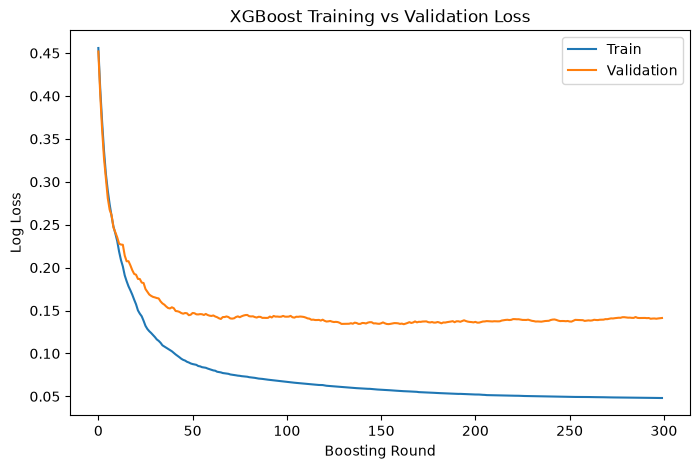

In [90]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

best_params = {
    k.replace("clf__", ""): v
    for k, v in search.best_params_.items()
}

xgb_standalone = XGBClassifier(eval_metric="logloss", random_state=42, **best_params)

xgb_standalone.fit(
    X_train[features], y_train,
    eval_set=[(X_train[features], y_train), (X_val[features], y_val)],
    verbose=False
)

results = xgb_standalone.evals_result()
epochs = len(results["validation_0"]["logloss"])
x_axis = range(epochs)

plt.figure(figsize=(8, 5))
plt.plot(x_axis, results["validation_0"]["logloss"], label="Train")
plt.plot(x_axis, results["validation_1"]["logloss"], label="Validation")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Training vs Validation Loss")
plt.legend()
plt.show()

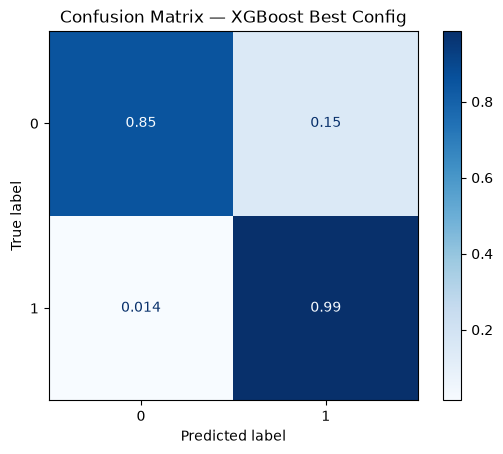

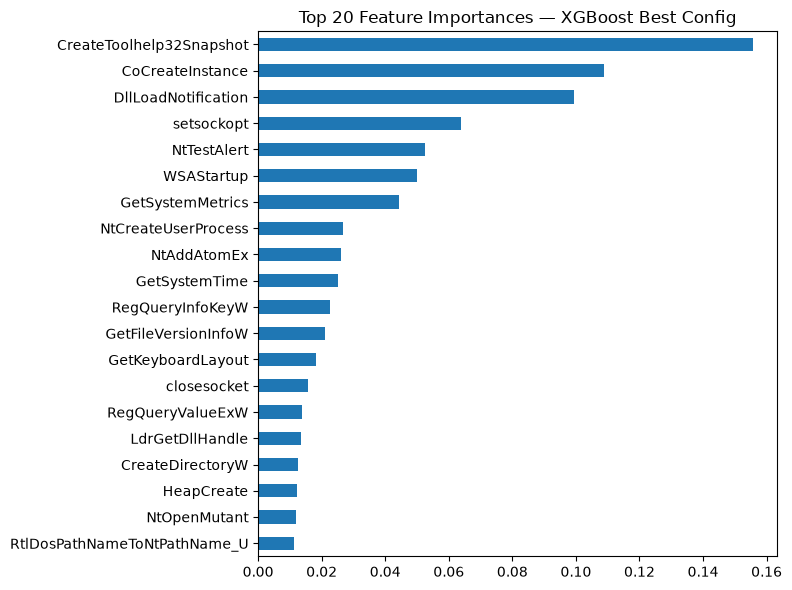

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, pred, cmap="Blues", normalize="true")
plt.title("Confusion Matrix — XGBoost Best Config")
plt.show()

# Feature importance
importances = pd.Series(best_model.named_steps["clf"].feature_importances_, index=features)
top_features = importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8,6))
top_features.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances — XGBoost Best Config")
plt.tight_layout(); plt.show()

# 3.2 Random Forest Experiments
- Random Forest with MI
- Random Forest with SMOTE and BorderlineSMOTE
- Random Forest with RF-importance feature selection

In [29]:
# Shared setup for experiments

import pandas as pd
import time
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = combined_df.copy()
X = df.drop(columns=["label"])
y = df["label"]

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_configs = {"Full": None, "Top 50": 50, "Top 100": 100, "Top 250": 250}

param_grid_base = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.5],
}

def select_features_mi(X_train, y_train, n=None):
    if n is None:
        return X_train.columns.tolist()
    mi = mutual_info_classif(X_train, y_train, random_state=42)
    ranked = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
    return ranked.head(n).index.tolist()

def select_features_rf_importance(X_train, y_train, n=None):
    if n is None:
        return X_train.columns.tolist()
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    importances = pd.Series(rf.feature_importances_, index=X_train.columns)
    return importances.sort_values(ascending=False).head(n).index.tolist()

def evaluate_fold(X_train, X_val, y_train, y_val, n_features, fold,
                   feature_set_name, select_fn, pipe, grid):
    start = time.perf_counter()

    features = select_fn(X_train, y_train, n_features)

    search = RandomizedSearchCV(
        pipe, grid, n_iter=20, scoring="f1",
        cv=inner_cv, random_state=42, n_jobs=-1
    )
    search.fit(X_train[features], y_train)

    best_model = search.best_estimator_
    pred = best_model.predict(X_val[features])
    prob = best_model.predict_proba(X_val[features])[:, 1]

    return {
        "fold": fold,
        "feature_set": feature_set_name,
        "n_features": len(features),
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, prob),
        "train_time": time.perf_counter() - start,
    }

def run_experiment(select_fn, pipe_builder, grid, label):
    """Runs nested CV across all feature_configs, returns results_df + summary."""
    results = [
        evaluate_fold(
            X.iloc[train_idx], X.iloc[val_idx],
            y.iloc[train_idx], y.iloc[val_idx],
            n_features, fold, feat_name, select_fn, pipe_builder(), grid
        )
        for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), 1)
        for feat_name, n_features in feature_configs.items()
    ]
    results_df = pd.DataFrame(results)
    summary = (
        results_df
        .groupby(["feature_set", "n_features"])[
            ["accuracy", "precision", "recall", "f1", "roc_auc"]
        ]
        .agg(["mean", "std"])
        .round(4)
    )
    return results_df, summary

## 3.2.1 Random Forest Baseline
- Random Forest with MI

In [96]:
def pipe_1():
    return ImbPipeline([("clf", RandomForestClassifier(random_state=42, n_jobs=-1))])

grid_1 = dict(param_grid_base)

results_df_1, summary_1 = run_experiment(select_features_mi, pipe_1, grid_1, "mi_none")
display(results_df_1)
display(summary_1)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.967391,0.972222,0.985915,0.979021,0.979209,11.064879
1,1,Top 50,50,0.956522,0.958904,0.985915,0.972222,0.987257,9.147613
2,1,Top 100,100,0.967391,0.972222,0.985915,0.979021,0.988598,9.115939
3,1,Top 250,250,0.967391,0.972222,0.985915,0.979021,0.989940,9.541662
4,2,Full,340,0.967391,0.960000,1.000000,0.979592,0.982639,9.497257
5,2,Top 50,50,0.967391,0.960000,1.000000,0.979592,0.979861,7.651770
6,2,Top 100,100,0.956522,0.947368,1.000000,0.972973,0.981944,7.887972
7,2,Top 250,250,0.967391,0.960000,1.000000,0.979592,0.981250,9.662133
8,3,Full,340,0.956522,0.972222,0.972222,0.972222,0.990972,8.166304
9,3,Top 50,50,0.923913,0.922078,0.986111,0.953020,0.976389,7.577169


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9454  0.0281    0.9515  0.0239  0.9804  0.0160   
Top 100     100          0.9433  0.0213    0.9465  0.0204  0.9832  0.0117   
Top 250     250          0.9455  0.0234    0.9491  0.0213  0.9832  0.0117   
Top 50      50           0.9346  0.0257    0.9342  0.0234  0.9860  0.0100   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9656  0.0175  0.9812  0.0060  
Top 100     100         0.9644  0.0131  0.9844  0.0039  
Top 250     250         0.9658  0.0144  0.9829  0.0070  
Top 50      50          0.9593  0.0156  0.9833  0.0052

## 3.2.2 Random Forest with SMOTE

In [97]:
def pipe_2():
    return ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ])

grid_2 = dict(param_grid_base)

results_df_2, summary_2 = run_experiment(select_features_mi, pipe_2, grid_2, "mi_smote")
display(results_df_2)
display(summary_2)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.956522,0.985507,0.957746,0.971429,0.989269,11.172776
1,1,Top 50,50,0.956522,0.971831,0.971831,0.971831,0.991952,9.636532
2,1,Top 100,100,0.934783,0.971014,0.943662,0.957143,0.986922,8.897476
3,1,Top 250,250,0.956522,0.971831,0.971831,0.971831,0.990275,10.634368
4,2,Full,340,0.967391,0.972603,0.986111,0.979310,0.992361,11.178219
5,2,Top 50,50,0.956522,0.959459,0.986111,0.972603,0.991667,9.622207
6,2,Top 100,100,0.967391,0.972603,0.986111,0.979310,0.994444,10.247330
7,2,Top 250,250,0.967391,0.972603,0.986111,0.979310,0.993056,11.323831
8,3,Full,340,0.923913,0.933333,0.972222,0.952381,0.978819,11.237666
9,3,Top 50,50,0.923913,0.957746,0.944444,0.951049,0.979861,8.329081


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9499  0.0199    0.9670  0.0197  0.9692  0.0185   
Top 100     100          0.9455  0.0172    0.9665  0.0072  0.9636  0.0213   
Top 250     250          0.9543  0.0178    0.9672  0.0198  0.9748  0.0119   
Top 50      50           0.9455  0.0133    0.9639  0.0071  0.9665  0.0159   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9679  0.0125  0.9889  0.0071  
Top 100     100         0.9649  0.0114  0.9896  0.0058  
Top 250     250         0.9709  0.0110  0.9889  0.0065  
Top 50      50          0.9651  0.0087  0.9867  0.0055

## 3.2.3 Random Forest with BorderlineSMOTE

In [98]:
def pipe_3():
    return ImbPipeline([
        ("smote", BorderlineSMOTE(random_state=42)),
        ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ])

grid_3 = dict(param_grid_base)

results_df_3, summary_3 = run_experiment(select_features_mi, pipe_3, grid_3, "mi_borderlinesmote")
display(results_df_3)
display(summary_3)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.956522,0.985507,0.957746,0.971429,0.989269,11.426941
1,1,Top 50,50,0.956522,0.971831,0.971831,0.971831,0.989269,9.942110
2,1,Top 100,100,0.967391,0.985714,0.971831,0.978723,0.989940,10.425330
3,1,Top 250,250,0.934783,0.985075,0.929577,0.956522,0.986586,11.392738
4,2,Full,340,0.956522,0.972222,0.972222,0.972222,0.986111,10.699415
5,2,Top 50,50,0.978261,0.986111,0.986111,0.986111,0.991667,9.723398
6,2,Top 100,100,0.956522,0.959459,0.986111,0.972603,0.987500,9.696540
7,2,Top 250,250,0.945652,0.958904,0.972222,0.965517,0.986806,10.875401
8,3,Full,340,0.934783,0.945946,0.972222,0.958904,0.977778,11.390528
9,3,Top 50,50,0.902174,0.920000,0.958333,0.938776,0.977778,9.688182


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9542  0.0162    0.9722  0.0163  0.9692  0.0119   
Top 100     100          0.9521  0.0165    0.9647  0.0219  0.9748  0.0119   
Top 250     250          0.9477  0.0141    0.9696  0.0171  0.9636  0.0215   
Top 50      50           0.9477  0.0281    0.9645  0.0273  0.9692  0.0117   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9706  0.0102  0.9878  0.0070  
Top 100     100         0.9695  0.0100  0.9870  0.0063  
Top 250     250         0.9663  0.0093  0.9874  0.0075  
Top 50      50          0.9667  0.0174  0.9867  0.0053

## 3.2.4 Random Forest with RF-importance Feature Selection

In [99]:
def pipe_4():
    return ImbPipeline([("clf", RandomForestClassifier(random_state=42, n_jobs=-1))])

grid_4 = dict(param_grid_base)

results_df_4, summary_4 = run_experiment(select_features_rf_importance, pipe_4, grid_4, "rfimp_none")
display(results_df_4)
display(summary_4)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.967391,0.972222,0.985915,0.979021,0.979209,8.357809
1,1,Top 50,50,0.956522,0.971831,0.971831,0.971831,0.993964,8.911297
2,1,Top 100,100,0.956522,0.971831,0.971831,0.971831,0.979879,8.552349
3,1,Top 250,250,0.967391,0.972222,0.985915,0.979021,0.988598,9.698518
4,2,Full,340,0.967391,0.960000,1.000000,0.979592,0.982639,10.639475
5,2,Top 50,50,0.956522,0.947368,1.000000,0.972973,0.991667,8.825054
6,2,Top 100,100,0.967391,0.960000,1.000000,0.979592,0.989583,8.251235
7,2,Top 250,250,0.967391,0.960000,1.000000,0.979592,0.973264,8.564623
8,3,Full,340,0.956522,0.972222,0.972222,0.972222,0.990972,8.174861
9,3,Top 50,50,0.923913,0.933333,0.972222,0.952381,0.981944,7.894888


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9454  0.0281    0.9515  0.0239  0.9804  0.0160   
Top 100     100          0.9411  0.0215    0.9464  0.0205  0.9804  0.0126   
Top 250     250          0.9389  0.0287    0.9393  0.0266  0.9860  0.0100   
Top 50      50           0.9346  0.0234    0.9389  0.0233  0.9804  0.0126   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9656  0.0175  0.9812  0.0060  
Top 100     100         0.9630  0.0132  0.9831  0.0073  
Top 250     250         0.9620  0.0175  0.9793  0.0100  
Top 50      50          0.9591  0.0143  0.9774  0.0187

## 3.2.5 Random Forest with RF-importance and SMOTE Balancing

In [100]:
def pipe_5():
    return ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ])

grid_5 = dict(param_grid_base)

results_df_5, summary_5 = run_experiment(select_features_rf_importance, pipe_5, grid_5, "rfimp_smote")
display(results_df_5)
display(summary_5)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.956522,0.985507,0.957746,0.971429,0.989269,11.492902
1,1,Top 50,50,0.967391,0.985714,0.971831,0.978723,0.993293,9.979851
2,1,Top 100,100,0.967391,0.985714,0.971831,0.978723,0.988934,10.426980
3,1,Top 250,250,0.967391,0.985714,0.971831,0.978723,0.985915,11.353070
4,2,Full,340,0.967391,0.972603,0.986111,0.979310,0.992361,11.296838
5,2,Top 50,50,0.967391,0.960000,1.000000,0.979592,0.991667,8.624072
6,2,Top 100,100,0.978261,0.972973,1.000000,0.986301,0.989583,10.709037
7,2,Top 250,250,0.967391,0.972603,0.986111,0.979310,0.988194,11.463201
8,3,Full,340,0.923913,0.933333,0.972222,0.952381,0.978819,11.093308
9,3,Top 50,50,0.934783,0.945946,0.972222,0.958904,0.985417,9.904844


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9499  0.0199    0.9670  0.0197  0.9692  0.0185   
Top 100     100          0.9564  0.0173    0.9671  0.0150  0.9776  0.0161   
Top 250     250          0.9520  0.0213    0.9671  0.0198  0.9720  0.0173   
Top 50      50           0.9455  0.0206    0.9564  0.0176  0.9748  0.0154   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9679  0.0125  0.9889  0.0071  
Top 100     100         0.9722  0.0109  0.9886  0.0054  
Top 250     250         0.9694  0.0134  0.9871  0.0065  
Top 50      50          0.9654  0.0129  0.9884  0.0038

## 3.2.6 Random Forest with RF-importance and BorderlineSMOTE balancing

In [101]:
def pipe_6():
    return ImbPipeline([
        ("smote", BorderlineSMOTE(random_state=42)),
        ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ])

grid_6 = dict(param_grid_base)

results_df_6, summary_6 = run_experiment(select_features_rf_importance, pipe_6, grid_6, "rfimp_borderlinesmote")
display(results_df_6)
display(summary_6)

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time
0,1,Full,340,0.956522,0.985507,0.957746,0.971429,0.989269,11.141358
1,1,Top 50,50,0.956522,0.971831,0.971831,0.971831,0.993964,10.420598
2,1,Top 100,100,0.967391,0.985714,0.971831,0.978723,0.990610,10.551733
3,1,Top 250,250,0.956522,0.985507,0.957746,0.971429,0.989269,11.503068
4,2,Full,340,0.956522,0.972222,0.972222,0.972222,0.986111,10.655461
5,2,Top 50,50,0.956522,0.959459,0.986111,0.972603,0.992014,9.928355
6,2,Top 100,100,0.967391,0.972603,0.986111,0.979310,0.990278,10.601997
7,2,Top 250,250,0.967391,0.972603,0.986111,0.979310,0.991667,11.594885
8,3,Full,340,0.934783,0.945946,0.972222,0.958904,0.977778,11.327658
9,3,Top 50,50,0.934783,0.958333,0.958333,0.958333,0.977431,9.899754


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9542  0.0162    0.9722  0.0163  0.9692  0.0119   
Top 100     100          0.9608  0.0165    0.9752  0.0173  0.9748  0.0119   
Top 250     250          0.9520  0.0167    0.9695  0.0144  0.9692  0.0185   
Top 50      50           0.9455  0.0109    0.9639  0.0071  0.9665  0.0125   

                            f1         roc_auc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9706  0.0102  0.9878  0.0070  
Top 100     100         0.9749  0.0103  0.9882  0.0073  
Top 250     250         0.9692  0.0107  0.9878  0.0103  
Top 50      50          0.9651  0.0070  0.9867  0.0067

## 3.2.7 Summary and Evaluation

In [109]:
all_results = pd.concat([
    results_df_1.assign(selection="MI", imbalance="none"),
    results_df_2.assign(selection="MI", imbalance="smote"),
    results_df_3.assign(selection="MI", imbalance="b_smote"),
    results_df_4.assign(selection="RF_importance", imbalance="none"),
    results_df_5.assign(selection="RF_importance", imbalance="smote"),
    results_df_6.assign(selection="RF_importance", imbalance="b_smote"),
], ignore_index=True)

summary_all = (
    all_results
    .groupby(["selection", "imbalance", "feature_set", "n_features"])[
        ["accuracy", "precision", "recall", "f1", "roc_auc"]
    ]
    .agg(["mean", "std"])
    .round(4)
)

# Sort by mean F1 descending
sorted_by_f1 = summary_all.sort_values(("f1", "mean"), ascending=False)
display(sorted_by_f1)

display(all_results)

accuracy         precision  \
                                                   mean     std      mean   
selection     imbalance feature_set n_features                              
RF_importance b_smote   Top 100     100          0.9608  0.0165    0.9752   
              smote     Top 100     100          0.9564  0.0173    0.9671   
MI            smote     Top 250     250          0.9543  0.0178    0.9672   
              b_smote   Full        340          0.9542  0.0162    0.9722   
RF_importance b_smote   Full        340          0.9542  0.0162    0.9722   
MI            b_smote   Top 100     100          0.9521  0.0165    0.9647   
RF_importance smote     Top 250     250          0.9520  0.0213    0.9671   
              b_smote   Top 250     250          0.9520  0.0167    0.9695   
MI            smote     Full        340          0.9499  0.0199    0.9670   
RF_importance smote     Full        340          0.9499  0.0199    0.9670   
MI            b_smote   Top 50      50           0.9477  0.0281    0.9645   
                        Top 250     250          0.9477  0.0141    0.9696   
              none      Top 250     250          0.9455  0.0234    0.9491   
RF_importance none      Full        340          0.9454  0.0281    0.9515   
MI            none      Full        340          0.9454  0.0281    0.9515   
RF_importance smote     Top 50      50           0.9455  0.0206    0.9564   
MI            smote     Top 50      50           0.9455  0.0133    0.9639   
RF_importance b_smote   Top 50      50           0.9455  0.0109    0.9639   
MI            smote     Top 100     100          0.9455  0.0172    0.9665   
              none      Top 100     100          0.9433  0.0213    0.9465   
RF_importance none      Top 100     100          0.9411  0.0215    0.9464   
                        Top 250     250          0.9389  0.0287    0.9393   
MI            none      Top 50      50           0.9346  0.0257    0.9342   
RF_importance none      Top 50      50           0.9346  0.0234    0.9389   

                                                        recall          \
                                                   std    mean     std   
selection     imbalance feature_set n_features                           
RF_importance b_smote   Top 100     100         0.0173  0.9748  0.0119   
              smote     Top 100     100         0.0150  0.9776  0.0161   
MI            smote     Top 250     250         0.0198  0.9748  0.0119   
              b_smote   Full        340         0.0163  0.9692  0.0119   
RF_importance b_smote   Full        340         0.0163  0.9692  0.0119   
MI            b_smote   Top 100     100         0.0219  0.9748  0.0119   
RF_importance smote     Top 250     250         0.0198  0.9720  0.0173   
              b_smote   Top 250     250         0.0144  0.9692  0.0185   
MI            smote     Full        340         0.0197  0.9692  0.0185   
RF_importance smote     Full        340         0.0197  0.9692  0.0185   
MI            b_smote   Top 50      50          0.0273  0.9692  0.0117   
                        Top 250     250         0.0171  0.9636  0.0215   
              none      Top 250     250         0.0213  0.9832  0.0117   
RF_importance none      Full        340         0.0239  0.9804  0.0160   
MI            none      Full        340         0.0239  0.9804  0.0160   
RF_importance smote     Top 50      50          0.0176  0.9748  0.0154   
MI            smote     Top 50      50          0.0071  0.9665  0.0159   
RF_importance b_smote   Top 50      50          0.0071  0.9665  0.0125   
MI            smote     Top 100     100         0.0072  0.9636  0.0213   
              none      Top 100     100         0.0204  0.9832  0.0117   
RF_importance none      Top 100     100         0.0205  0.9804  0.0126   
                        Top 250     250         0.0266  0.9860  0.0100   
MI            none      Top 50      50          0.0234  0.9860  0.0100   
RF_importance none      Top 50      50     

,fold,feature_set,n_features,accuracy,precision,recall,f1,roc_auc,train_time,selection,imbalance
0,1,Full,340,0.967391,0.972222,0.985915,0.979021,0.979209,11.064879,MI,none
1,1,Top 50,50,0.956522,0.958904,0.985915,0.972222,0.987257,9.147613,MI,none
2,1,Top 100,100,0.967391,0.972222,0.985915,0.979021,0.988598,9.115939,MI,none
3,1,Top 250,250,0.967391,0.972222,0.985915,0.979021,0.989940,9.541662,MI,none
4,2,Full,340,0.967391,0.960000,1.000000,0.979592,0.982639,9.497257,MI,none
...,...,...,...,...,...,...,...,...,...,...,...
115,4,Top 250,250,0.967391,0.972603,0.986111,0.979310,0.998611,11.340592,RF_importance,b_smote
116,5,Full,340,0.945055,0.971429,0.957746,0.964539,0.988732,10.493732,RF_importance,b_smote
117,5,Top 50,50,0.945055,0.971429,0.957746,0.964539,0.986620,9.999637,RF_importance,b_smote
118,5,Top 100,100,0.956044,0.985507,0.957746,0.971429,0.986972,10.533780,RF_importance,b_smote


From this table we can see that the best configuration is **Random Forest with RF Importance feature selection, Borderline SMOTE Balancing, with top 100 features**, having good overall performance with roc_auc score within margins.

In [110]:
# Mean feature set according to F1 mean summary

best_config_results = results_df_6[
    (results_df_6["feature_set"] == "Top 100")
]
mean_f1 = best_config_results["f1"].mean()
best_config_results["dist_from_mean"] = (best_config_results["f1"] - mean_f1).abs()

representative_fold = best_config_results.sort_values("dist_from_mean").iloc[0]["fold"]
print(f"Representative fold: {representative_fold}, F1: {best_config_results.sort_values('dist_from_mean').iloc[0]['f1']}")

Representative fold: 5, F1: 0.9714285714285714


In [111]:
# Best configs according to F1 mean summary using representative fold

fold_splits = list(outer_cv.split(X, y))
train_idx, val_idx = fold_splits[4]

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

# Random Forest with RF-importance and BorderlineSMOTE balancing using top 100 features
features = select_features_rf_importance(X_train, y_train, n=100)

pipe = ImbPipeline([
    ("smote", BorderlineSMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

grid = dict(param_grid_base)

search = RandomizedSearchCV(
    pipe, grid, n_iter=20, scoring="f1",
    cv=inner_cv, random_state=42, n_jobs=-1
)
search.fit(X_train[features], y_train)

best_model = search.best_estimator_
pred = best_model.predict(X_val[features])
prob = best_model.predict_proba(X_val[features])[:, 1]

In [112]:
# Test Best Representation model

from sklearn.metrics import f1_score
print(f1_score(y_val, pred))

0.9714285714285714


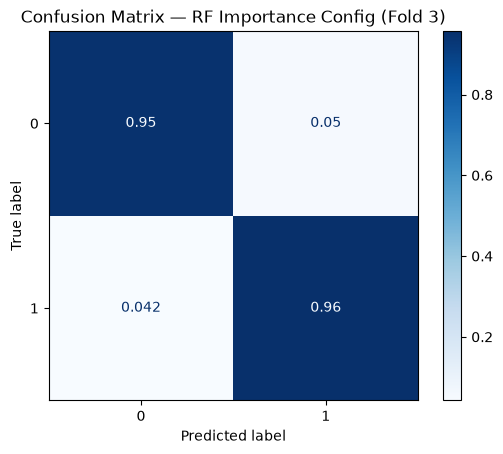

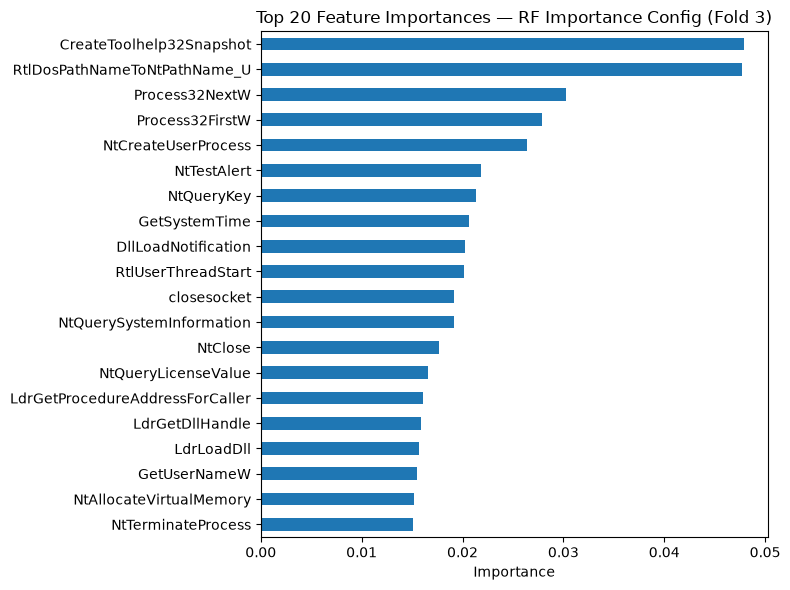

In [113]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, pred, cmap="Blues", normalize="true")
plt.title("Confusion Matrix — RF Importance Config (Fold 3)")
plt.show()

# Feature importance
importances = pd.Series(best_model.named_steps["clf"].feature_importances_, index=features)
top_features = importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
top_features.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances — RF Importance Config (Fold 3)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 3.3 Logistic Regression Experiments

In [15]:
import pandas as pd
import time
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PowerTransformer, FunctionTransformer, QuantileTransformer, StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, matthews_corrcoef, f1_score
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = combined_df.copy()
X = df.drop(columns=["label"])
y = df["label"]

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#feature_configs = {"Top 50": 50, "Top 100": 100, "Top 250": 250}
feature_configs = {"Full": None, "Top 50": 50, "Top 100": 100, "Top 250": 250}

def select_features_mi(X_train, y_train, n=None):
    if n is None:
        return X_train.columns.tolist()
    mi = mutual_info_classif(X_train, y_train, random_state=42)
    ranked = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
    return ranked.head(n).index.tolist()

METRIC_COLS = ["accuracy", "precision", "recall", "f1", "mcc"]

def evaluate_fold(X_train, X_val, y_train, y_val, n_features, fold,
                  feature_set_name, select_fn, pipe, grid):
    start = time.perf_counter()

    features = select_fn(X_train, y_train, n_features)

    search = GridSearchCV(pipe, grid, scoring="f1_macro", cv=inner_cv, n_jobs=-1)
    search.fit(X_train[features], y_train)

    pred = search.best_estimator_.predict(X_val[features])

    return {
        "fold": fold,
        "feature_set": feature_set_name,
        "n_features": len(features),
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "mcc": matthews_corrcoef(y_val, pred),
        "best_params": str(search.best_params_),
        "train_time": time.perf_counter() - start,
    }

def run_experiment(select_fn, pipe_builder, grid, label, configs=feature_configs):
    results = [
        evaluate_fold(
            X.iloc[train_idx], X.iloc[val_idx],
            y.iloc[train_idx], y.iloc[val_idx],
            n_features, fold, feat_name, select_fn, pipe_builder(), grid
        )
        for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), 1)
        for feat_name, n_features in configs.items()
    ]
    results_df = pd.DataFrame(results)
    summary = (
        results_df
        .groupby(["feature_set", "n_features"])[METRIC_COLS]
        .agg(["mean", "std"])
        .round(4)
    )
    return results_df, summary

grid_l2 = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}

## 3.3.1 Logistic Regression baseline
- Using Log1p Transformation, StandardScaler, Mutual info classifier

In [42]:
def pipe_1():
    return ImbPipeline([
        ("log", FunctionTransformer(np.log1p)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(l1_ratio=0, solver="liblinear", max_iter=5000, random_state=42)),
    ])

results_df_1, summary_1 = run_experiment(select_features_mi, pipe_1, grid_l2, "mi_none")
display(results_df_1)
display(summary_1)

,fold,feature_set,n_features,accuracy,precision,recall,f1,mcc,best_params,train_time
0,1,Full,340,0.945652,0.958333,0.971831,0.965035,0.843526,{'clf__C': 1},2.578550
1,1,Top 50,50,0.956522,0.985507,0.957746,0.971429,0.882171,{'clf__C': 1},0.739369
2,1,Top 100,100,0.967391,1.000000,0.957746,0.978417,0.915439,{'clf__C': 1},0.726682
3,1,Top 250,250,0.945652,0.971429,0.957746,0.964539,0.848676,{'clf__C': 0.1},0.773981
4,2,Full,340,0.934783,0.971429,0.944444,0.957746,0.816567,{'clf__C': 10},0.291477
5,2,Top 50,50,0.913043,0.970588,0.916667,0.942857,0.767125,{'clf__C': 1},0.783183
6,2,Top 100,100,0.923913,0.957746,0.944444,0.951049,0.780739,{'clf__C': 100},0.798447
7,2,Top 250,250,0.923913,0.971014,0.930556,0.950355,0.791155,{'clf__C': 0.1},0.985220
8,3,Full,340,0.913043,0.970588,0.916667,0.942857,0.767125,{'clf__C': 0.1},0.295494
9,3,Top 50,50,0.945652,0.971831,0.958333,0.965035,0.843526,{'clf__C': 1},0.804200


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9281  0.0145    0.9684  0.0056  0.9387  0.0231   
Top 100     100          0.9477  0.0222    0.9644  0.0227  0.9693  0.0229   
Top 250     250          0.9347  0.0287    0.9770  0.0160  0.9387  0.0318   
Top 50      50           0.9456  0.0188    0.9744  0.0062  0.9554  0.0227   

                            f1             mcc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9531  0.0099  0.8021  0.0338  
Top 100     100         0.9666  0.0141  0.8484  0.0675  
Top 250     250         0.9572  0.0192  0.8241  0.0726  
Top 50      50          0.9647  0.0125  0.8474  0.0471

## 3.3.2 Logistic Regression with Borderline SMOTE Balancing
- Using BorderLine SMOTE Balancing with baseline

In [43]:
def pipe_2():
    return ImbPipeline([
        ("log", FunctionTransformer(np.log1p)),
        ("scaler", StandardScaler()),
        ("smote", BorderlineSMOTE(random_state=42)),
        ("clf", LogisticRegression(l1_ratio=0, solver="liblinear", max_iter=5000, random_state=42)),
    ])

results_df_2, summary_2 = run_experiment(select_features_mi, pipe_2, grid_l2, "mi_smote")
display(results_df_2)
display(summary_2)

,fold,feature_set,n_features,accuracy,precision,recall,f1,mcc,best_params,train_time
0,1,Full,340,0.902174,0.955882,0.915493,0.935252,0.738505,{'clf__C': 100},0.531130
1,1,Top 50,50,0.923913,1.000000,0.901408,0.948148,0.822226,{'clf__C': 1},0.708403
2,1,Top 100,100,0.945652,1.000000,0.929577,0.963504,0.866494,{'clf__C': 10},0.753667
3,1,Top 250,250,0.923913,0.970588,0.929577,0.949640,0.797483,{'clf__C': 10},0.911020
4,2,Full,340,0.934783,0.971429,0.944444,0.957746,0.816567,{'clf__C': 1},0.463155
5,2,Top 50,50,0.902174,0.956522,0.916667,0.936170,0.730297,{'clf__C': 100},0.714923
6,2,Top 100,100,0.923913,0.957746,0.944444,0.951049,0.780739,{'clf__C': 100},0.774412
7,2,Top 250,250,0.913043,0.970588,0.916667,0.942857,0.767125,{'clf__C': 1},1.075065
8,3,Full,340,0.902174,0.970149,0.902778,0.935252,0.744336,{'clf__C': 1},0.528221
9,3,Top 50,50,0.923913,0.971014,0.930556,0.950355,0.791155,{'clf__C': 1},0.794787


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9172  0.0145    0.9706  0.0103  0.9218  0.0158   
Top 100     100          0.9390  0.0261    0.9694  0.0225  0.9526  0.0336   
Top 250     250          0.9108  0.0506    0.9786  0.0137  0.9053  0.0565   
Top 50      50           0.9325  0.0234    0.9743  0.0158  0.9385  0.0323   

                            f1             mcc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9455  0.0099  0.7787  0.0353  
Top 100     100         0.9605  0.0172  0.8308  0.0727  
Top 250     250         0.9399  0.0354  0.7784  0.1114  
Top 50      50          0.9557  0.0158  0.8175  0.0597

## 3.3.3 Logistic Regression with Robust Scaler
- Baseline with RobustScaler instead of StandardScaler

In [62]:
def pipe_3():
    return ImbPipeline([
        ("log", FunctionTransformer(np.log1p)),
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(l1_ratio=0, solver="liblinear", max_iter=5000, random_state=42)),
    ])

results_df_3, summary_3 = run_experiment(select_features_mi, pipe_3, grid_l2, "robustScaler_none")
display(results_df_3)
display(summary_3)

,fold,feature_set,n_features,accuracy,precision,recall,f1,mcc,best_params,train_time
0,1,Full,340,0.934783,0.957746,0.957746,0.957746,0.814889,{'clf__C': 1},0.386127
1,1,Top 50,50,0.913043,0.970149,0.915493,0.942029,0.773892,{'clf__C': 10},0.762987
2,1,Top 100,100,0.945652,0.971429,0.957746,0.964539,0.848676,{'clf__C': 1},0.795392
3,1,Top 250,250,0.967391,0.972222,0.985915,0.979021,0.906313,{'clf__C': 1},0.856518
4,2,Full,340,0.934783,0.971429,0.944444,0.957746,0.816567,{'clf__C': 0.1},0.323405
5,2,Top 50,50,0.923913,0.957746,0.944444,0.951049,0.780739,{'clf__C': 10},0.853198
6,2,Top 100,100,0.923913,0.957746,0.944444,0.951049,0.780739,{'clf__C': 100},0.854807
7,2,Top 250,250,0.934783,0.971429,0.944444,0.957746,0.816567,{'clf__C': 100},0.862220
8,3,Full,340,0.923913,0.933333,0.972222,0.952381,0.767533,{'clf__C': 1},0.305361
9,3,Top 50,50,0.945652,0.971831,0.958333,0.965035,0.843526,{'clf__C': 10},0.759934


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9368  0.0119    0.9563  0.0232  0.9637  0.0158   
Top 100     100          0.9434  0.0259    0.9589  0.0209  0.9693  0.0229   
Top 250     250          0.9478  0.0235    0.9645  0.0250  0.9694  0.0180   
Top 50      50           0.9390  0.0196    0.9688  0.0062  0.9525  0.0236   

                            f1             mcc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9597  0.0072  0.8156  0.0402  
Top 100     100         0.9639  0.0165  0.8345  0.0779  
Top 250     250         0.9667  0.0145  0.8471  0.0739  
Top 50      50          0.9604  0.0134  0.8284  0.0482

## 3.3.4 Logistic Regression with Robust Scaler and Borderline SMOTE Balancing

In [63]:
def pipe_4():
    return ImbPipeline([
        ("log", FunctionTransformer(np.log1p)),
        ("scaler", RobustScaler()),
        ("smote", BorderlineSMOTE(random_state=42)),
        ("clf", LogisticRegression(l1_ratio=0, solver="liblinear", max_iter=5000, random_state=42)),
    ])

results_df_4, summary_4 = run_experiment(select_features_mi, pipe_4, grid_l2, "robustScaler_smote")
display(results_df_4)
display(summary_4)

,fold,feature_set,n_features,accuracy,precision,recall,f1,mcc,best_params,train_time
0,1,Full,340,0.923913,0.970588,0.929577,0.949640,0.797483,{'clf__C': 0.1},0.427216
1,1,Top 50,50,0.923913,1.000000,0.901408,0.948148,0.822226,{'clf__C': 1},0.805012
2,1,Top 100,100,0.934783,0.971014,0.943662,0.957143,0.822362,{'clf__C': 100},0.867619
3,1,Top 250,250,0.934783,0.971014,0.943662,0.957143,0.822362,{'clf__C': 10},0.880829
4,2,Full,340,0.945652,0.971831,0.958333,0.965035,0.843526,{'clf__C': 10},0.355311
5,2,Top 50,50,0.913043,0.957143,0.930556,0.943662,0.754788,{'clf__C': 100},0.845687
6,2,Top 100,100,0.923913,0.957746,0.944444,0.951049,0.780739,{'clf__C': 100},0.834264
7,2,Top 250,250,0.923913,0.971014,0.930556,0.950355,0.791155,{'clf__C': 10},0.911636
8,3,Full,340,0.923913,0.945205,0.958333,0.951724,0.772686,{'clf__C': 10},0.366112
9,3,Top 50,50,0.934783,0.971429,0.944444,0.957746,0.816567,{'clf__C': 10},0.854286


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Full        340          0.9434  0.0193    0.9691  0.0147  0.9581  0.0199   
Top 100     100          0.9368  0.0281    0.9585  0.0208  0.9610  0.0302   
Top 250     250          0.9347  0.0297    0.9661  0.0208  0.9498  0.0232   
Top 50      50           0.9369  0.0193    0.9745  0.0156  0.9441  0.0299   

                            f1             mcc          
                          mean     std    mean     std  
feature_set n_features                                  
Full        340         0.9635  0.0127  0.8389  0.0542  
Top 100     100         0.9595  0.0182  0.8188  0.0802  
Top 250     250         0.9578  0.0190  0.8150  0.0872  
Top 50      50          0.9587  0.0132  0.8275  0.0485

## 3.3.5 Summary of Results from experiment 1 to 4

In [80]:
lg_all_results = pd.concat([
    results_df_1.assign(pre="log1p",scaler="Standard", imbalance="none"),
    results_df_2.assign(pre="log1p",scaler="Standard", imbalance="smote"),
    results_df_3.assign(pre="log1p",scaler="Robust", imbalance="none"),
    results_df_4.assign(pre="log1p",scaler="Robust", imbalance="smote"),
], ignore_index=True)

lg_summary_all = (
    lg_all_results
    .groupby(["pre","scaler", "imbalance", "feature_set"])[METRIC_COLS]
    .agg(["mean", "std"])
    .round(4)
)

sorted_by_f1 = lg_summary_all.sort_values(("f1", "mean"), ascending=False)

display(sorted_by_f1)

accuracy         precision          \
                                         mean     std      mean     std   
pre   scaler   imbalance feature_set                                      
log1p Robust   none      Top 250       0.9478  0.0235    0.9645  0.0250   
      Standard none      Top 100       0.9477  0.0222    0.9644  0.0227   
                         Top 50        0.9456  0.0188    0.9744  0.0062   
      Robust   none      Top 100       0.9434  0.0259    0.9589  0.0209   
               smote     Full          0.9434  0.0193    0.9691  0.0147   
      Standard smote     Top 100       0.9390  0.0261    0.9694  0.0225   
      Robust   none      Top 50        0.9390  0.0196    0.9688  0.0062   
                         Full          0.9368  0.0119    0.9563  0.0232   
               smote     Top 100       0.9368  0.0281    0.9585  0.0208   
                         Top 50        0.9369  0.0193    0.9745  0.0156   
                         Top 250       0.9347  0.0297    0.9661  0.0208   
      Standard none      Top 250       0.9347  0.0287    0.9770  0.0160   
               smote     Top 50        0.9325  0.0234    0.9743  0.0158   
               none      Full          0.9281  0.0145    0.9684  0.0056   
               smote     Full          0.9172  0.0145    0.9706  0.0103   
                         Top 250       0.9108  0.0506    0.9786  0.0137   

                                      recall              f1             mcc  \
                                        mean     std    mean     std    mean   
pre   scaler   imbalance feature_set                                           
log1p Robust   none      Top 250      0.9694  0.0180  0.9667  0.0145  0.8471   
      Standard none      Top 100      0.9693  0.0229  0.9666  0.0141  0.8484   
                         Top 50       0.9554  0.0227  0.9647  0.0125  0.8474   
      Robust   none      Top 100      0.9693  0.0229  0.9639  0.0165  0.8345   
               smote     Full         0.9581  0.0199  0.9635  0.0127  0.8389   
      Standard smote     Top 100      0.9526  0.0336  0.9605  0.0172  0.8308   
      Robust   none      Top 50       0.9525  0.0236  0.9604  0.0134  0.8284   
                         Full         0.9637  0.0158  0.9597  0.0072  0.8156   
               smote     Top 100      0.9610  0.0302  0.9595  0.0182  0.8188   
                         Top 50       0.9441  0.0299  0.9587  0.0132  0.8275   
                         Top 250      0.9498  0.0232  0.9578  0.0190  0.8150   
      Standard none      Top 250      0.9387  0.0318  0.9572  0.0192  0.8241   
               smote     Top 50       0.9385  0.0323  0.9557  0.0158  0.8175   
               none      Full         0.9387  0.0231  0.9531  0.0099  0.8021   
               smote     Full         0.9218  0.0158  0.9455  0.0099  0.7787   
                         Top 250      0.9053  0.0565  0.9399  0.0354  0.7784   

                                              
                                         std  
pre   scaler   imbalance feature_set          
log1p Robust   none      Top 250      0.0739  
      Standard none      Top 100      0.0675  
                         Top 50       0.0471  
      Robust   none      Top 100      0.0779  
               smote     Full         0.0542  
      Standard smote     Top 100      0.0727  
      Robust   none      Top 50       0.0482  
                         Full         0.0402  
               smote     Top 100      0.0802  
                         Top 50       0.0485  
                         Top 250      0.0872  
      Standard none      Top 250      0.0726  
               smote     Top 50       0.0597  
               none      Full         0.0338  
               smote     Full         0.0353  
                         Top 250      0.1114

## 3.3.6 Testing Yeo Johnson PowerTransformer instead of Log1p
- Testing Yeo Johnson PowerTransformer using best configuration from previous experiments.

In [23]:
def pipe_5():
    return ImbPipeline([
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(l1_ratio=0, solver="liblinear", max_iter=5000, random_state=42)),
    ])

results_df_5, summary_5 = run_experiment(select_features_mi, pipe_5, grid_l2, "yeoj_robustScaler_none")
display(results_df_5)
display(summary_5)

,fold,feature_set,n_features,accuracy,precision,recall,f1,mcc,best_params,train_time
0,1,Top 50,50,0.934783,0.957746,0.957746,0.957746,0.814889,{'clf__C': 10},4.819423
1,1,Top 100,100,0.945652,0.971429,0.957746,0.964539,0.848676,{'clf__C': 1},8.591253
2,1,Top 250,250,0.934783,0.971014,0.943662,0.957143,0.822362,{'clf__C': 1},22.593029
3,2,Top 50,50,0.934783,0.958333,0.958333,0.958333,0.808333,{'clf__C': 100},5.041359
4,2,Top 100,100,0.913043,0.957143,0.930556,0.943662,0.754788,{'clf__C': 10},9.326033
5,2,Top 250,250,0.945652,0.958904,0.972222,0.965517,0.837784,{'clf__C': 10},21.668174
6,3,Top 50,50,0.934783,0.958333,0.958333,0.958333,0.808333,{'clf__C': 10},5.170574
7,3,Top 100,100,0.902174,0.920000,0.958333,0.938776,0.699636,{'clf__C': 1},9.240983
8,3,Top 250,250,0.923913,0.922078,0.986111,0.953020,0.766099,{'clf__C': 1},22.466637
9,4,Top 50,50,0.978261,1.000000,0.972222,0.985915,0.940127,{'clf__C': 100},4.722338


accuracy         precision          recall          \
                           mean     std      mean     std    mean     std   
feature_set n_features                                                      
Top 100     100          0.9391  0.0303    0.9536  0.0196  0.9693  0.0302   
Top 250     250          0.9521  0.0250    0.9676  0.0298  0.9720  0.0173   
Top 50      50           0.9521  0.0237    0.9694  0.0182  0.9693  0.0182   

                            f1             mcc          
                          mean     std    mean     std  
feature_set n_features                                  
Top 100     100         0.9612  0.0193  0.8219  0.0914  
Top 250     250         0.9695  0.0156  0.8605  0.0757  
Top 50      50          0.9693  0.0153  0.8615  0.0698

### Comparison of previous results

In [82]:
lg_all_results = pd.concat([
    results_df_1.assign(pre="log1p",scaler="Standard", imbalance="none"),
    results_df_2.assign(pre="log1p",scaler="Standard", imbalance="smote"),
    results_df_3.assign(pre="log1p",scaler="Robust", imbalance="none"),
    results_df_4.assign(pre="log1p",scaler="Robust", imbalance="smote"),
    results_df_5.assign(pre="yeoj",scaler="Robust", imbalance="none")
], ignore_index=True)

lg_summary_all = (
    lg_all_results
    .groupby(["pre","scaler", "imbalance", "feature_set"])[METRIC_COLS]
    .agg(["mean", "std"])
    .round(4)
)

sorted_by_f1 = lg_summary_all.sort_values(("f1", "mean"), ascending=False)

display(sorted_by_f1)

accuracy         precision          \
                                         mean     std      mean     std   
pre   scaler   imbalance feature_set                                      
yeoj  Robust   none      Top 250       0.9521  0.0250    0.9676  0.0298   
                         Top 50        0.9521  0.0237    0.9694  0.0182   
                         Full          0.9521  0.0145    0.9721  0.0093   
log1p Robust   none      Top 250       0.9478  0.0235    0.9645  0.0250   
      Standard none      Top 100       0.9477  0.0222    0.9644  0.0227   
                         Top 50        0.9456  0.0188    0.9744  0.0062   
      Robust   none      Top 100       0.9434  0.0259    0.9589  0.0209   
               smote     Full          0.9434  0.0193    0.9691  0.0147   
yeoj  Robust   none      Top 100       0.9391  0.0303    0.9536  0.0196   
log1p Standard smote     Top 100       0.9390  0.0261    0.9694  0.0225   
      Robust   none      Top 50        0.9390  0.0196    0.9688  0.0062   
                         Full          0.9368  0.0119    0.9563  0.0232   
               smote     Top 100       0.9368  0.0281    0.9585  0.0208   
                         Top 50        0.9369  0.0193    0.9745  0.0156   
                         Top 250       0.9347  0.0297    0.9661  0.0208   
      Standard none      Top 250       0.9347  0.0287    0.9770  0.0160   
               smote     Top 50        0.9325  0.0234    0.9743  0.0158   
               none      Full          0.9281  0.0145    0.9684  0.0056   
               smote     Full          0.9172  0.0145    0.9706  0.0103   
                         Top 250       0.9108  0.0506    0.9786  0.0137   

                                      recall              f1             mcc  \
                                        mean     std    mean     std    mean   
pre   scaler   imbalance feature_set                                           
yeoj  Robust   none      Top 250      0.9720  0.0173  0.9695  0.0156  0.8605   
                         Top 50       0.9693  0.0182  0.9693  0.0153  0.8615   
                         Full         0.9664  0.0236  0.9691  0.0099  0.8638   
log1p Robust   none      Top 250      0.9694  0.0180  0.9667  0.0145  0.8471   
      Standard none      Top 100      0.9693  0.0229  0.9666  0.0141  0.8484   
                         Top 50       0.9554  0.0227  0.9647  0.0125  0.8474   
      Robust   none      Top 100      0.9693  0.0229  0.9639  0.0165  0.8345   
               smote     Full         0.9581  0.0199  0.9635  0.0127  0.8389   
yeoj  Robust   none      Top 100      0.9693  0.0302  0.9612  0.0193  0.8219   
log1p Standard smote     Top 100      0.9526  0.0336  0.9605  0.0172  0.8308   
      Robust   none      Top 50       0.9525  0.0236  0.9604  0.0134  0.8284   
                         Full         0.9637  0.0158  0.9597  0.0072  0.8156   
               smote     Top 100      0.9610  0.0302  0.9595  0.0182  0.8188   
                         Top 50       0.9441  0.0299  0.9587  0.0132  0.8275   
                         Top 250      0.9498  0.0232  0.9578  0.0190  0.8150   
      Standard none      Top 250      0.9387  0.0318  0.9572  0.0192  0.8241   
               smote     Top 50       0.9385  0.0323  0.9557  0.0158  0.8175   
               none      Full         0.9387  0.0231  0.9531  0.0099  0.8021   
               smote     Full         0.9218  0.0158  0.9455  0.0099  0.7787   
                         Top 250      0.9053  0.0565  0.9399  0.0354  0.7784   

                                              
                                         std  
pre   scaler   imbalance feature_set          
yeoj  Robust   none      Top 250      0.0757  
                         Top 50       0.0698  
                         Full         0.0358  
log1p Robust   none      Top 250      0.0739  
      Standard none      Top 100      0.0675  
                         Top 50       0.0471  
      Robust   none      Top 100      0.0779  


From this summary we can see that Yeo Johnson transformation has a better overall performance compare to log1p using the best configuration from log1p experiments. However, looking at the time taken, Yeo Johnson requires considerably more time to transform the dataset.

## 3.3.7 Yeo Johnson Experiments with Different Solvers
- Yeo Johnson experiments without using the full feature set (50, 100, 250). Reason why is because full feature set takes exponentially more time to transform compared to smaller feature sets.
- Additional Experiments on solvers using best preprocessing, scaler, and imbalance.

In [16]:
def pipe_6():
    return ImbPipeline([
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(l1_ratio=0, solver="saga", max_iter=5000, random_state=42)),
    ])

results_df_6, summary_6 = run_experiment(select_features_mi, pipe_6, grid_l2, "saga_yeoj_robustScaler_none")

print("done")

done


In [20]:
def pipe_7():
    return ImbPipeline([
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(l1_ratio=0, solver="newton-cg", max_iter=5000, random_state=42)),
    ])

results_df_7, summary_7 = run_experiment(select_features_mi, pipe_7, grid_l2, "newtoncg_yeoj_robustScaler_none")

print("done")

done


In [18]:
def pipe_8():
    return ImbPipeline([
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(l1_ratio=0, solver="newton-cholesky", max_iter=5000, random_state=42)),
    ])

results_df_8, summary_8 = run_experiment(select_features_mi, pipe_8, grid_l2, "newtoncs_yeoj_robustScaler_none")

print("done")

done


In [19]:
def pipe_9():
    return ImbPipeline([
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(l1_ratio=0, solver="lbfgs", max_iter=5000, random_state=42)),
    ])

results_df_9, summary_9 = run_experiment(select_features_mi, pipe_9, grid_l2, "lbfgs_yeoj_robustScaler_none")

print("done")

done


In [25]:
# using yeo johnson
lg_all_results = pd.concat([
    results_df_5.assign(solver="liblinear",scaler="Robust", imbalance="none"),
    results_df_6.assign(solver="saga",scaler="Robust", imbalance="none"),
    results_df_7.assign(solver="newton-cg",scaler="Robust", imbalance="none"),
    results_df_8.assign(solver="newton-cs",scaler="Robust", imbalance="none"),
    results_df_9.assign(solver="lbfgs",scaler="Robust", imbalance="none"),
], ignore_index=True)

lg_summary_all = (
    lg_all_results
    .groupby(["solver", "scaler", "imbalance", "feature_set"])[METRIC_COLS]
    .agg(["mean", "std"])
    .round(4)
)

sorted_by_f1 = lg_summary_all.sort_values(("f1", "mean"), ascending=False)

display(sorted_by_f1)

accuracy         precision          \
                                           mean     std      mean     std   
solver    scaler imbalance feature_set                                      
newton-cg Robust none      Top 250       0.9586  0.0222    0.9678  0.0298   
newton-cs Robust none      Top 250       0.9586  0.0222    0.9678  0.0298   
lbfgs     Robust none      Top 250       0.9565  0.0230    0.9652  0.0299   
saga      Robust none      Top 250       0.9543  0.0247    0.9648  0.0269   
liblinear Robust none      Top 250       0.9521  0.0250    0.9676  0.0298   
                           Top 50        0.9521  0.0237    0.9694  0.0182   
newton-cs Robust none      Top 50        0.9499  0.0211    0.9668  0.0186   
lbfgs     Robust none      Top 50        0.9478  0.0178    0.9640  0.0123   
newton-cg Robust none      Top 50        0.9456  0.0202    0.9638  0.0124   
                           Top 100       0.9434  0.0208    0.9589  0.0184   
saga      Robust none      Top 50        0.9434  0.0177    0.9611  0.0063   
liblinear Robust none      Top 100       0.9391  0.0303    0.9536  0.0196   
lbfgs     Robust none      Top 100       0.9390  0.0249    0.9561  0.0170   
saga      Robust none      Top 100       0.9390  0.0224    0.9588  0.0160   
newton-cs Robust none      Top 100       0.9369  0.0281    0.9559  0.0170   

                                        recall              f1          \
                                          mean     std    mean     std   
solver    scaler imbalance feature_set                                   
newton-cg Robust none      Top 250      0.9805  0.0075  0.9739  0.0135   
newton-cs Robust none      Top 250      0.9805  0.0075  0.9739  0.0135   
lbfgs     Robust none      Top 250      0.9805  0.0075  0.9725  0.0140   
saga      Robust none      Top 250      0.9777  0.0075  0.9711  0.0151   
liblinear Robust none      Top 250      0.9720  0.0173  0.9695  0.0156   
                           Top 50       0.9693  0.0182  0.9693  0.0153   
newton-cs Robust none      Top 50       0.9693  0.0182  0.9679  0.0136   
lbfgs     Robust none      Top 50       0.9693  0.0182  0.9665  0.0115   
newton-cg Robust none      Top 50       0.9665  0.0211  0.9651  0.0132   
                           Top 100      0.9693  0.0229  0.9639  0.0132   
saga      Robust none      Top 50       0.9665  0.0211  0.9637  0.0116   
liblinear Robust none      Top 100      0.9693  0.0302  0.9612  0.0193   
lbfgs     Robust none      Top 100      0.9665  0.0271  0.9611  0.0161   
saga      Robust none      Top 100      0.9637  0.0351  0.9608  0.0149   
newton-cs Robust none      Top 100      0.9638  0.0320  0.9596  0.0183   

                                           mcc          
                                          mean     std  
solver    scaler imbalance feature_set                  
newton-cg Robust none      Top 250      0.8777  0.0703  
newton-cs Robust none      Top 250      0.8777  0.0703  
lbfgs     Robust none      Top 250      0.8708  0.0726  
saga      Robust none      Top 250      0.8640  0.0786  
liblinear Robust none      Top 250      0.8605  0.0757  
                           Top 50       0.8615  0.0698  
newton-cs Robust none      Top 50       0.8550  0.0623  
lbfgs     Robust none      Top 50       0.8482  0.0517  
newton-cg Robust none      Top 50       0.8427  0.0581  
                           Top 100      0.8350  0.0634  
saga      Robust none      Top 50       0.8359  0.0502  
liblinear Robust none      Top 100      0.8219  0.0914  
lbfgs     Robust none      Top 100      0.8226  0.0732  
saga      Robust none      Top 100      0.8266  0.0630  
newton-cs Robust none      Top 100      0.8177  0.0794

From the table sorted by F1 score, we can see that newton-cg solver gives the best overall performance across the board.
Hence we conclude that **Log Regression with Yeo Johnson transformer, Robust Scaler, and newton-cg solver with top 250 features selected using Mutual Info Classifier** is the best configuration.

## 3.4 Dump JobLib for each model

## 3.4.1 XGBoost

In [27]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
import joblib

features = select_features_xgb_importance(X, y, n=None)
pipe = ImbPipeline([
    ("smote", BorderlineSMOTE(random_state=42)),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42)),
])
grid = param_grid_base

search = RandomizedSearchCV(pipe, grid, n_iter=20, scoring="f1", cv=inner_cv, random_state=42, n_jobs=-1)
search.fit(X[features], y)

xgb_final = search.best_estimator_
print(search.best_params_)

joblib.dump({"model": xgb_final, "features": features}, "xgb_final_model.joblib")

{'clf__subsample': 1.0, 'clf__n_estimators': 300, 'clf__min_child_weight': 1, 'clf__max_depth': 2, 'clf__learning_rate': 0.2, 'clf__gamma': 0.3, 'clf__colsample_bytree': 1.0}


['xgb_final_model.joblib']

## 3.4.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
import joblib

features = select_features_rf_importance(X, y, n=100)
pipe = ImbPipeline([
    ("smote", BorderlineSMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])
grid = param_grid_base

search = RandomizedSearchCV(pipe, grid, n_iter=20, scoring="f1", cv=inner_cv, random_state=42, n_jobs=-1)
search.fit(X[features], y)

rf_final = search.best_estimator_
print(search.best_params_)

joblib.dump({"model": rf_final, "features": features}, "rf_final_model.joblib")

{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': None}


['rf_final_model.joblib']

## 3.4.3 Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
import numpy as np
import joblib

features = select_features_mi(X, y, n=250)
pipe = ImbPipeline([
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", RobustScaler()),                          
    ("clf", LogisticRegression(l1_ratio=0, solver="newton-cg", max_iter=5000, random_state=42)),
])
grid = grid_l2

search = GridSearchCV(pipe, grid, scoring="f1", cv=inner_cv, n_jobs=-1)
search.fit(X[features], y)

lr_final = search.best_estimator_
print(search.best_params_)

joblib.dump({"model": lr_final, "features": features}, "lr_final_model.joblib")

{'clf__C': 1}


['lr_final_model.joblib']

## 3.4.4 Feature Dicitonary
- List of API calls used for traning.
- To refer to when creating new dataset for anylysis jobs

In [14]:
import pandas as pd

combined_df.copy()
X = df.drop(columns=["label"])

all_training_columns = X.columns.tolist()

pd.Series(all_training_columns).to_csv("feature_dictionary.csv", index=False, header=["api_calls"])